Small [[18, 4, 4]] BB code as an example

In [1]:
import stim
import sys
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

In [2]:
l = 3
m = 2
Aij = [[0, 0], [0, 1]]  # A = I + y
Bij = [[0, 0], [1, 1], [2, 0]]  # B = I + xy + x^2 
d = 2
code = get_code_params(l, m, Aij, Bij, d)
    

## Alternatively can use functions from bbparamfuncs.py, e.g.
# code = bb6_18_4_4() # above code
# code = bb5_12_4_2() # smallest bb code I've found that isn't an iceberg code, nice for testing circuits
# code = gross_code() # the gross code from original Bravyi paper

print(f"BB code [[{code.n}, {code.k}, {code.d_max}]]\nl = {code.l}, m = {code.m}\nA = {code.A}\nB = {code.B}")

BB code [[12, 4, 2]]
l = 3, m = 2
A = x^0⋅y^0 + x^0⋅y^1
B = x^0⋅y^0 + x^1⋅y^1 + x^2⋅y^0


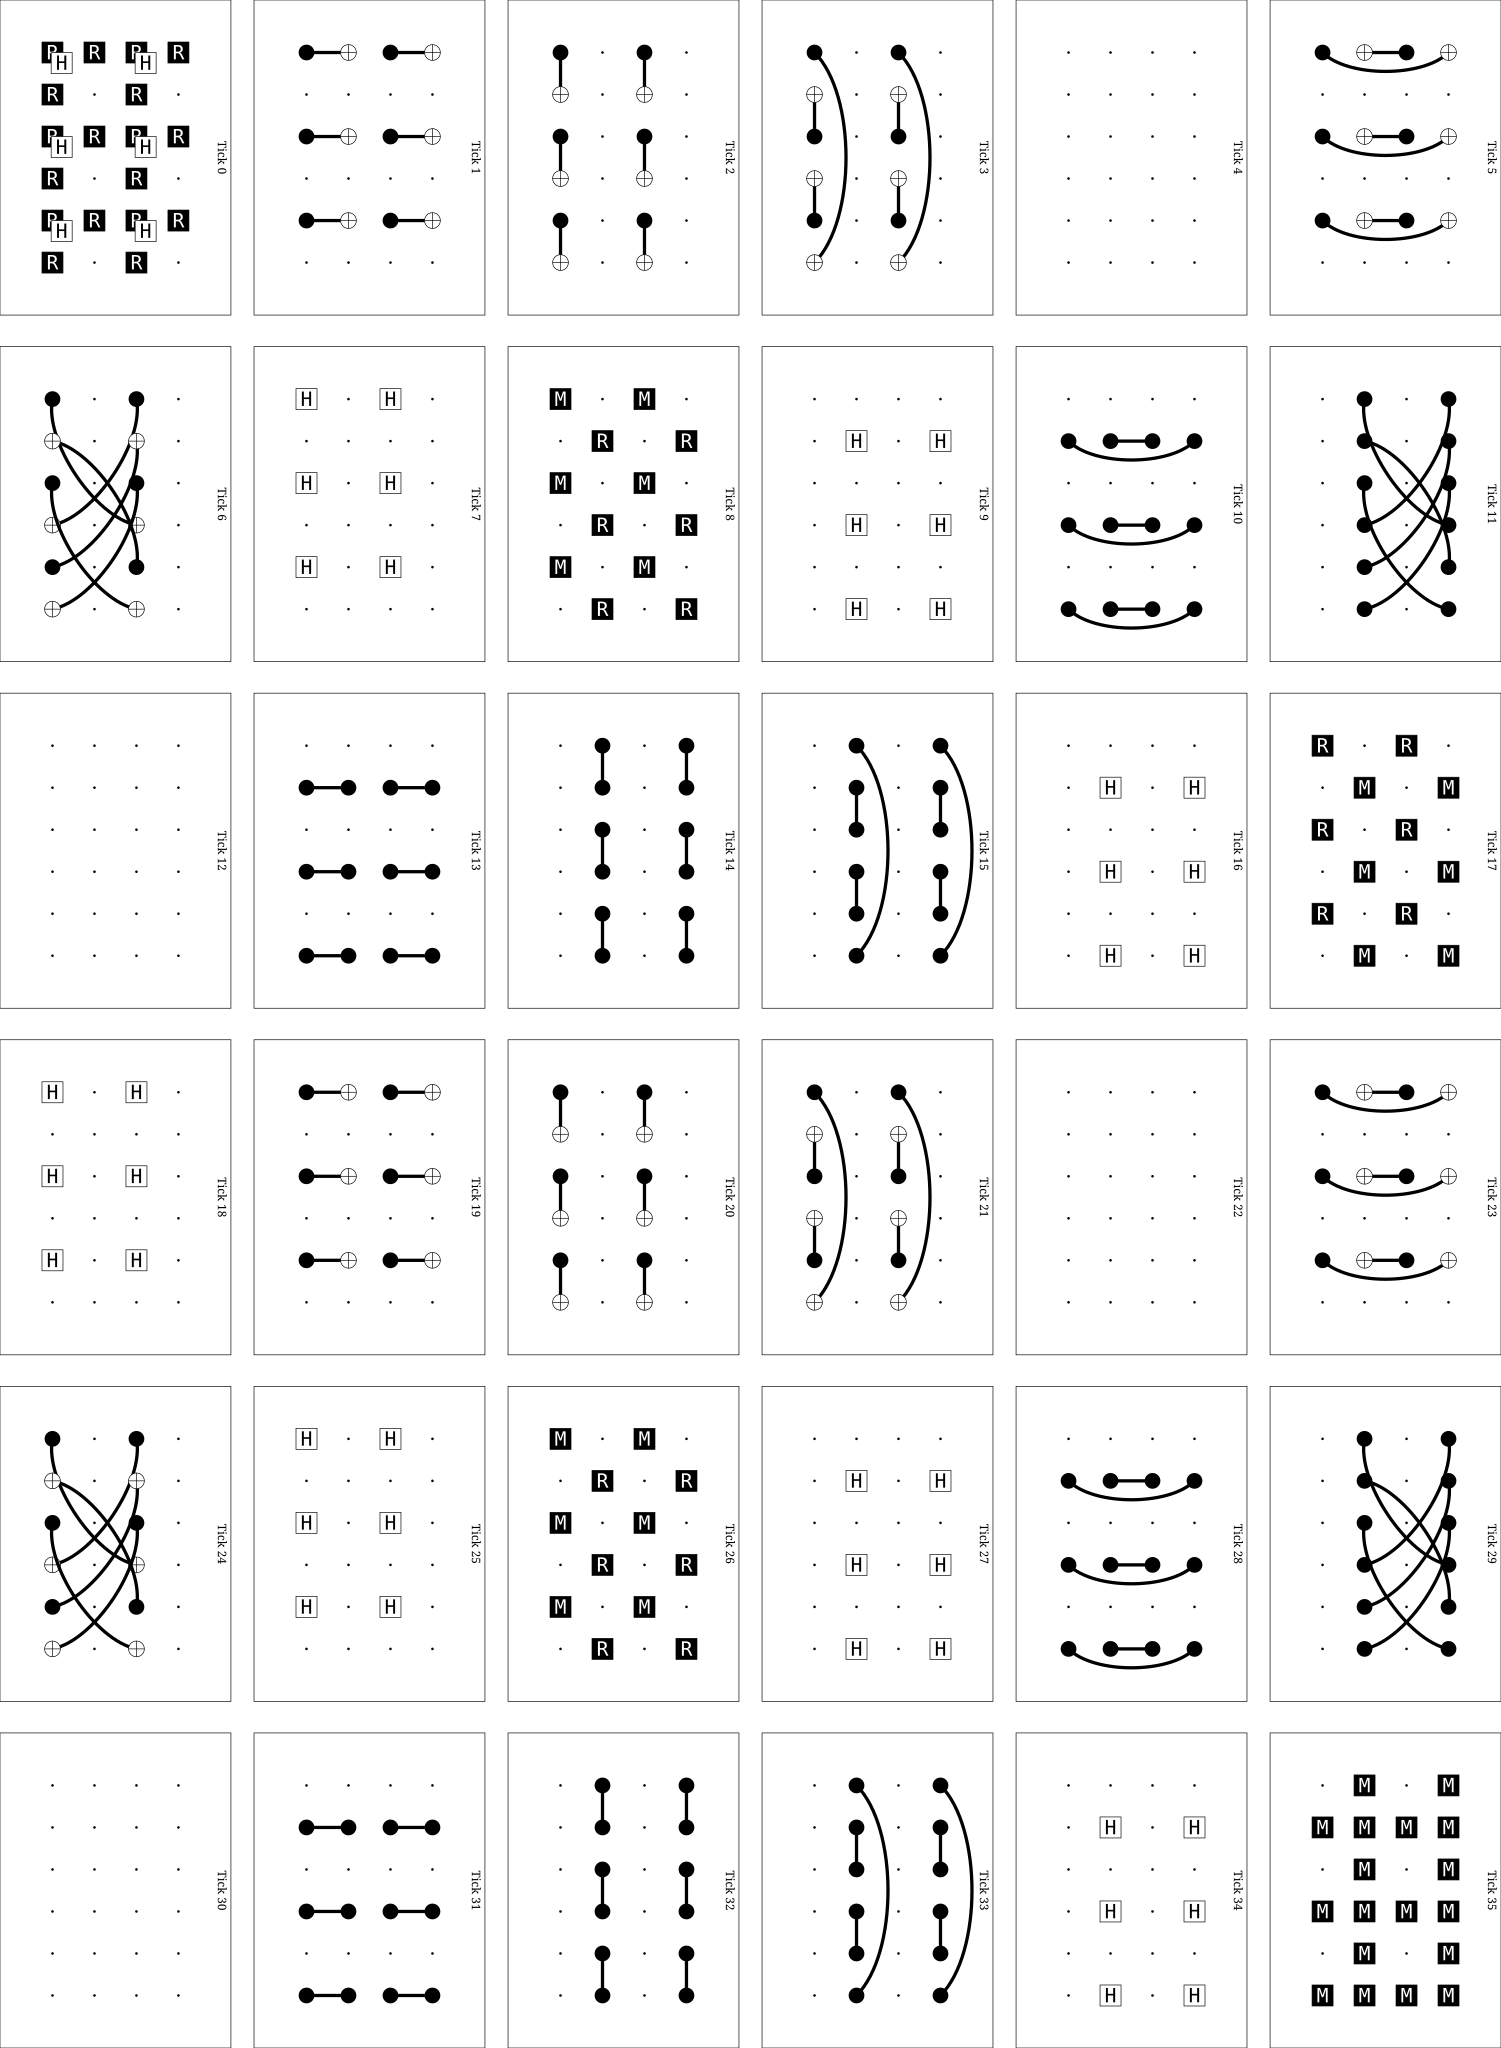

In [3]:
# Visualise its circuit
p = 0.001
circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
    code,  
    errors = tham_modules_errors(p), # see src/bb_ions/noisefuncs for different noise models
    idle_during = tham_modules_idle_errors(p),
    num_syndrome_extraction_cycles = code.d_max,  
    memory_basis = 'Z',)

# display(circuit.without_noise().diagram("timeline-svg"))
display(circuit.without_noise().diagram("timeslice-svg"))
# order_of_ops(code) # print this line to see the order of terms (a term is x^i*y^j) being applied for the two-qubit gates.

In [4]:
# Generate circuits:

# Clear last example circuits and remake directories:
empty_folder('example_circuits')
empty_folder('example_circuit_diagrams')

ps = [0.001, 0.002] # physical error rate values
memory_basis = 'Z'
num_rounds = code.d_max

for p in ps:

    circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
        code,  
        errors = tham_modules_errors(p), # see src/bb_ions/noisefuncs for different noise models
        idle_during = tham_modules_idle_errors(p),
        num_syndrome_extraction_cycles = num_rounds,  
        memory_basis = 'Z',
    )

    

    # Save circuit:
    filename = f"nkd=[[{code.n}_{code.k}_{code.d_max}]],p={p},b={memory_basis},r={num_rounds},l={l},m={m},A='{''.join(str(x) + str(y) for x, y in Aij)}',B='{''.join(str(x) + str(y) for x, y in Bij)}'"
    circuit.to_file(f"example_circuits/{filename}.stim")

In [5]:
# # Run memory experiment simulations:

import sinter
import glob
from stimbposd import SinterDecoder_BPOSD, sinter_decoders
import multiprocessing

circuit_paths = glob.glob(f"example_circuits/nkd=[[{code.n}_{code.k}_{code.d_max}*.stim")

csv_path = "example_stats/collected_stats.csv"

tasks = [
    sinter.Task(
        circuit_path = path,
        json_metadata = sinter.comma_separated_key_values(path),
    )
    for path in circuit_paths
]


empty_folder('example_stats') # clear previous example stats

# Collect new stats:
samples = sinter.collect(
    num_workers=multiprocessing.cpu_count(),
    max_shots=1000,
    print_progress = True,
    max_errors=100,
    tasks = tasks,
    decoders=['bposd'],
    save_resume_filepath = csv_path,
    custom_decoders = {
        "bposd": SinterDecoder_BPOSD( # using settings from Ye Delfosse long chain paper [2503.22071] as I have found this to be very fast for only a small hit to performance.
            max_bp_iters = 10_000, 
            bp_method = "min_sum", 
            osd_method = "osd_cs", 
            osd_order = 5 
        )
    },
    )

Starting 8 workers...
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                             
        4   bposd <1m        750          95 nkd=[[12_4_2]],p=0.001,b=Z,r=2,l=3,m=2,A='0001',B='001120'
        4   bposd   ?       1000         100 nkd=[[12_4_2]],p=0.002,b=Z,r=2,l=3,m=2,A='0001',B='001120'
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                             
        4   bposd <1m        500          91 nkd=[[12_4_2]],p=0.001,b=Z,r=2,l=3,m=2,A='0001',B='001120'
        4   bposd   ?       1000         100 nkd=[[12_4_2]],p=0.002,b=Z,r=2,l=3,m=2,A='0001',B='001120'
2 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                             
        4   bposd <1m        250          80 nkd=[[12_4_2]],p=0.001,b=Z,r=2,l=3,m=2,A='0001',B='001120'
        4   bposd <1m        983          99 nkd=[[12_4_2]],p=0.002,b=Z,r=2,l=3,m=2,A='0001',B='001120'


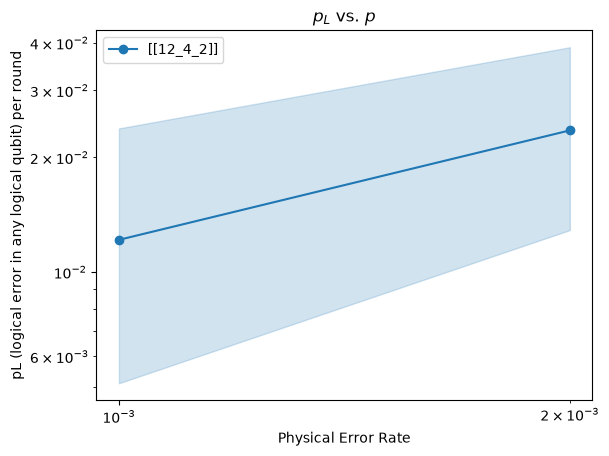

In [6]:
# Plot results:

import matplotlib.pyplot as plt

# Plot:
collected_stats = sinter.stats_from_csv_files(f'example_stats/collected_stats.csv')

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['nkd'],
    failure_units_per_shot_func = lambda stats: stats.json_metadata['r'], # set as num_rounds ('r') failure units to find pL per round
)

ax.loglog()
ax.legend()
ax.set_title("$p_L$ vs. $p$")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("pL (logical error in any logical qubit) per round");